In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
sentiment = pd.read_csv(r"C:\Users\HP\Desktop\Trader-Sentiment-Analysis\data\fear_greed_index.csv")
trades = pd.read_csv(r"C:\Users\HP\Desktop\Trader-Sentiment-Analysis\data\historical_data.csv")

In [2]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

print("\nMissing values:\n", trades.isnull().sum())
print("\nDuplicates:", trades.duplicated().sum())

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

Missing values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates: 0


In [5]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [6]:
# Standardize column names
sentiment.columns = sentiment.columns.str.lower()
trades.columns = trades.columns.str.lower()

# Convert datetime (FIXED)
sentiment['date'] = pd.to_datetime(sentiment['date'])

trades['timestamp ist'] = pd.to_datetime(
    trades['timestamp ist'],
    dayfirst=True,
    errors='coerce'
)

# Extract date
sentiment['date'] = sentiment['date'].dt.date
trades['date'] = trades['timestamp ist'].dt.date

# Step 4: Rename columns
trades = trades.rename(columns={
    'closed pnl': 'closed_pnl'
})

# Merge
df = trades.merge(
    sentiment[['date', 'classification']],
    on='date',
    how='left'
)

In [7]:
print(df[['timestamp ist','date']].head())
print(df.isnull().sum())

        timestamp ist        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02
account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed_pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
date                0
classification      6
dtype: int64


In [18]:
df = df.dropna(subset=['classification'])
df.isnull().sum()

account             0
coin                0
execution price     0
size tokens         0
size usd            0
side                0
timestamp ist       0
start position      0
direction           0
closed_pnl          0
transaction hash    0
order id            0
crossed             0
fee                 0
trade id            0
timestamp           0
date                0
classification      0
win                 0
is_long             0
dtype: int64

In [10]:
# Create win column
df['win'] = df['closed_pnl'] > 0

# (optional but useful)
df['is_long'] = (df['side'] == 'BUY').astype(int)

In [11]:
# Avg PnL
pnl_by_sentiment = df.groupby('classification')['closed_pnl'].mean()

# Win Rate
win_rate = df.groupby('classification')['win'].mean()

# Avg Trade Size
size_by_sentiment = df.groupby('classification')['size usd'].mean()

print("PnL:\n", pnl_by_sentiment)
print("\nWin Rate:\n", win_rate)
print("\nTrade Size:\n", size_by_sentiment)

PnL:
 classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closed_pnl, dtype: float64

Win Rate:
 classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

Trade Size:
 classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: size usd, dtype: float64


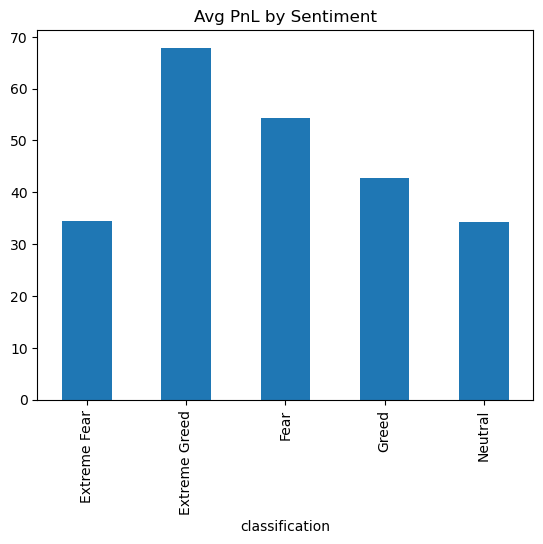

In [14]:
pnl_by_sentiment.plot(kind='bar', title='Avg PnL by Sentiment')
plt.savefig(r'C:\Users\HP\Desktop\Trader-Sentiment-Analysis\charts\pnl_vs_sentiment.png')
plt.show()

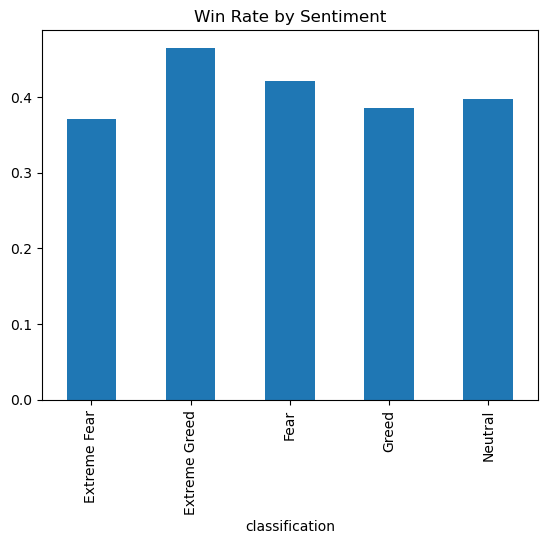

In [15]:
win_rate.plot(kind='bar', title='Win Rate by Sentiment')
plt.savefig(r'C:\Users\HP\Desktop\Trader-Sentiment-Analysis\charts\winrate_vs_sentiment.png')
plt.show()

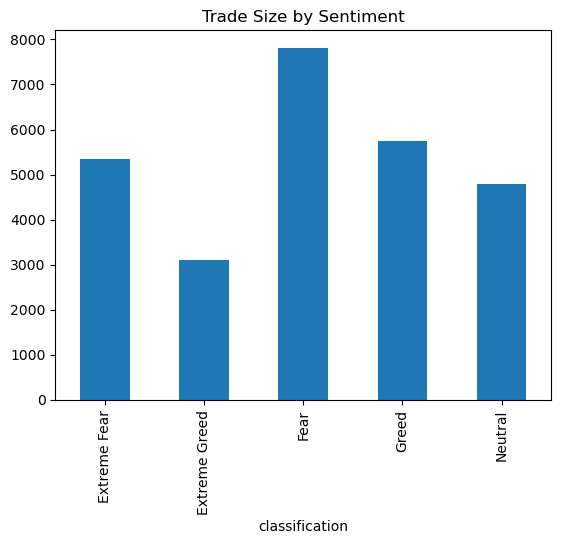

In [16]:
size_by_sentiment.plot(kind='bar', title='Trade Size by Sentiment')
plt.savefig(r'C:\Users\HP\Desktop\Trader-Sentiment-Analysis\charts\trade_size.png')
plt.show()